In [ ]:
# Off-policy Advantage Actor-Critic Method(A2C)

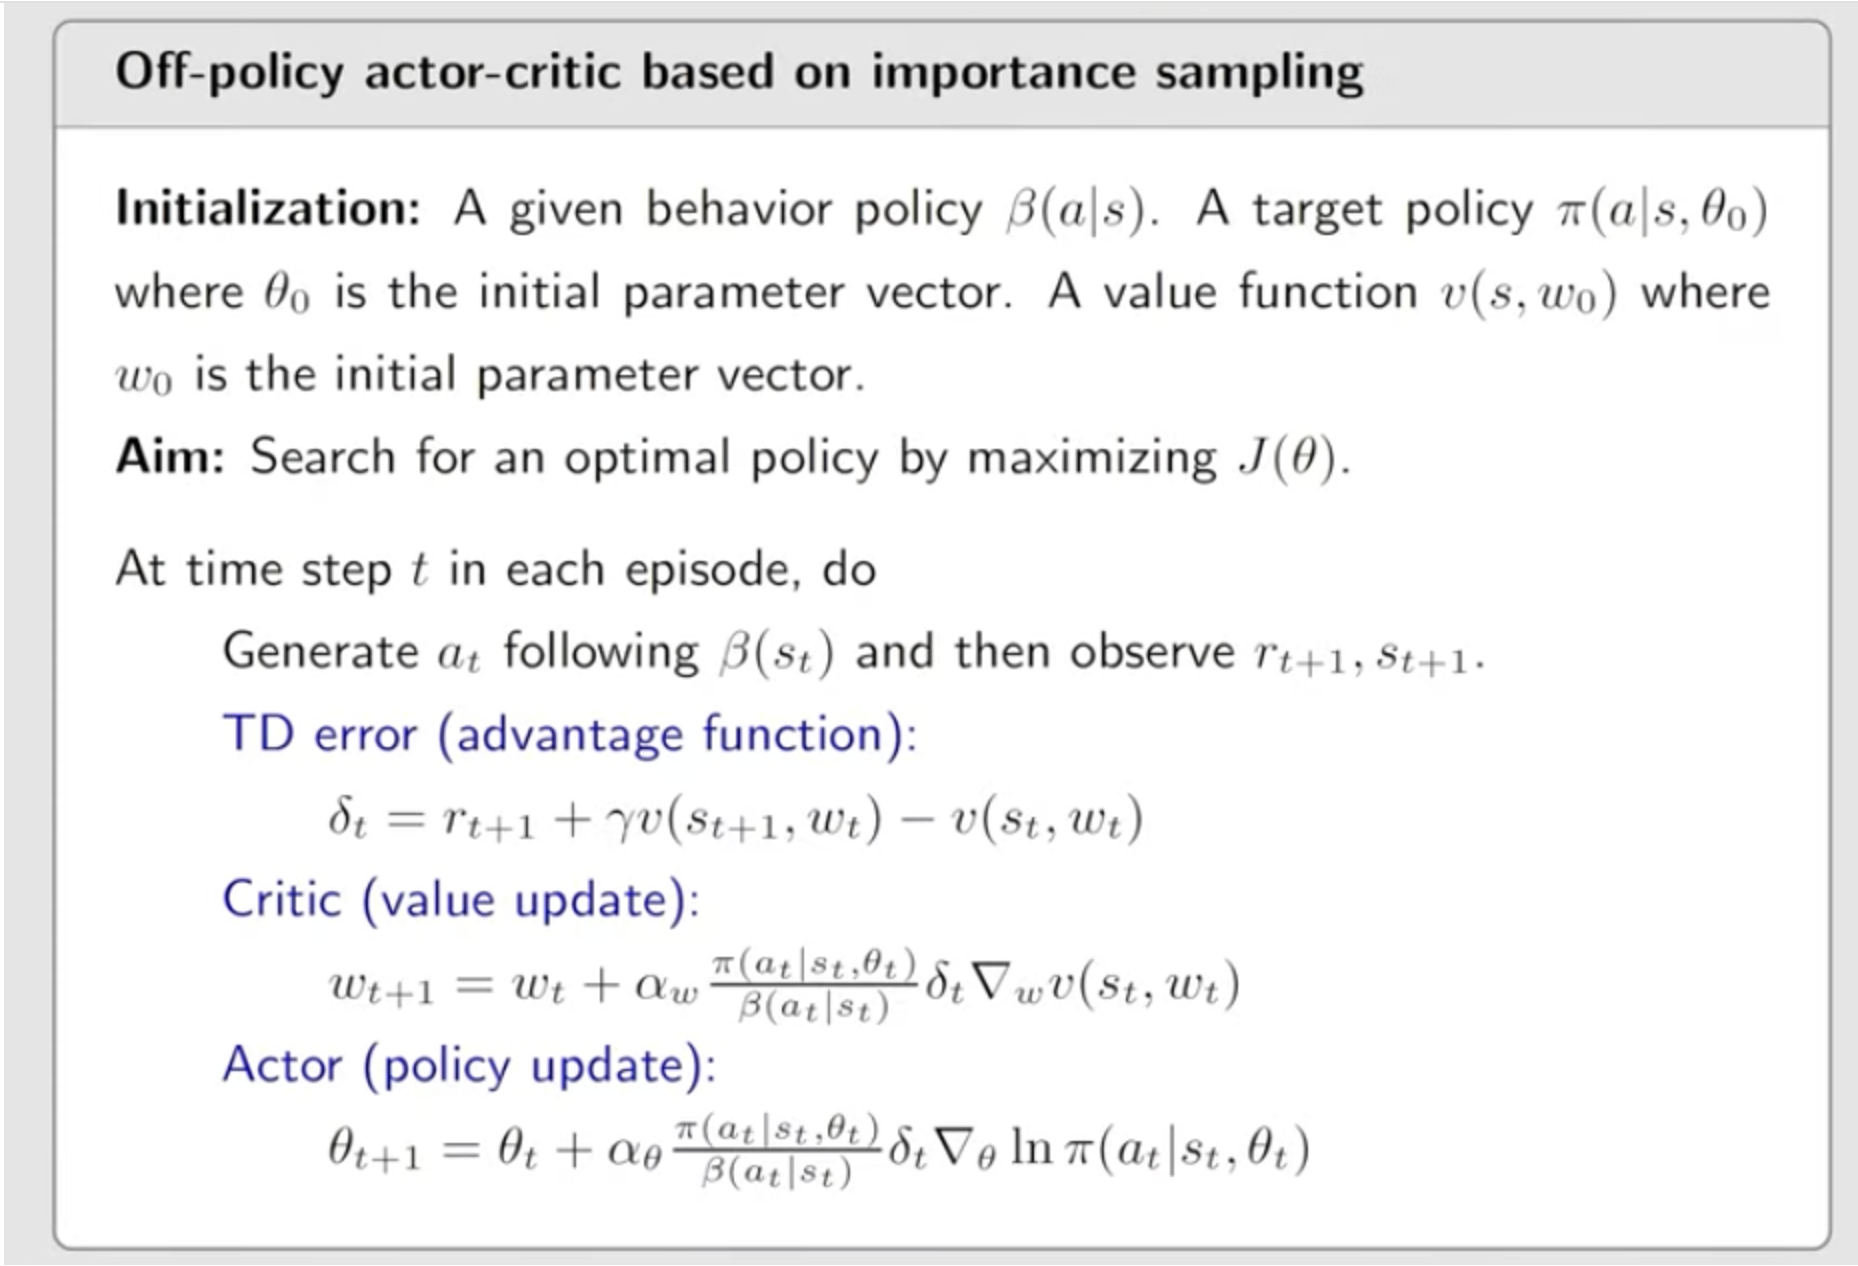

In [ ]:
import random
import math
import torch
from torch import nn 
from torch import optim
from collections import deque
from torch.distributions import Categorical

from frozen_lake_environment import (generate_grid_randomly,
                                     FrozenLakeEnvironment,
                                     State)
import numpy as np
from matplotlib import pyplot
from visual_utils import (render_policy_and_value, 
                          animate_policy_value_video,
                          plot_trajectory_history)
import torch.nn.functional as F
from tqdm import tqdm

In [ ]:
lake_grid = [["G", "H", "F", "F"],
             ["F", "F", "F", "F"],
             ["F", "F", "H", "F"],
             ["F", "H", "S", "F"]]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [ ]:
class BehaviourActor(nn.Module):
    """
    Policy network π(a | s; θ).
    Outputs a categorical distribution over discrete actions.
    """
    def __init__(self, state_dim: int, act_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, act_dim)
        )

    def forward(self, x: torch.Tensor) -> Categorical:
        logits = self.net(x)
        return Categorical(logits=logits)

    def log_prob(self, x: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        return self.forward(x).log_prob(a)
            
    def policy_table(self, env):
        states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
        policy = np.zeros(env.n_states, dtype=np.int8)
        for state in states:
            state_vec = state.get_state_feature_vec(env.n_states)
            state_vec = torch.Tensor(state_vec).unsqueeze(0) # 1 X feat_vec
            with torch.no_grad():
                action_probs = self.forward(state_vec).probs
                policy[state.idx] = torch.argmax(action_probs, dim=-1).item()
        return policy

In [ ]:
class TargetActor(nn.Module):
    """
    Policy network π(a | s; θ).
    Outputs a categorical distribution over discrete actions.
    """
    def __init__(self, state_dim: int, act_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, act_dim)
        )

    def forward(self, x: torch.Tensor) -> Categorical:
        logits = self.net(x)
        return Categorical(logits=logits)

    def log_prob(self, x: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        return self.forward(x).log_prob(a)
            
    def policy_table(self, env):
        states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
        policy = np.zeros(env.n_states, dtype=np.int8)
        for state in states:
            state_vec = state.get_state_feature_vec(env.n_states)
            state_vec = torch.Tensor(state_vec).unsqueeze(0) # 1 X feat_vec
            with torch.no_grad():
                action_probs = self.forward(state_vec).probs
                policy[state.idx] = torch.argmax(action_probs, dim=-1).item()
        return policy

In [ ]:
class Critic(nn.Module):
    """
    state-value network V(s; φ).
    Outputs one scalar per discrete action → index by chosen action.
    """
    def __init__(self, state_dim: int, act_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Returns Q-values for all actions, shape (batch, act_dim)."""
        return self.net(x)
    def v_table(self, env):
        states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
        V = np.zeros(env.n_states, dtype=np.float32)
        for state in states:
            state_feat_vec = state.get_state_feature_vec(env.n_states)
            state_feat_vec = torch.Tensor(state_feat_vec).unsqueeze(0) # 1 X feat_vec
            with torch.no_grad():
                v_value = self.forward(state_feat_vec).squeeze(1)
            V[state.idx] = v_value.item()
        return V

In [ ]:
critic = Critic(frozen_lake.n_states, frozen_lake.n_actions)
critic

In [ ]:
state_vec = frozen_lake.find('S').get_state_feature_vec(frozen_lake.n_states)
state_vec = torch.Tensor(state_vec).unsqueeze(0)
state_vec.shape

In [ ]:
critic(state_vec)

In [ ]:
critic.v_table(frozen_lake)

In [ ]:
class OffPolicyA2CAgent:
    def __init__(self, env, behaviour_actor, target_actor,
                 critic, lr_actor, lr_critic, gamma):
        
        self.env = env
        self.behaviour_actor = behaviour_actor
        self.target_actor = target_actor
        self.critic = critic                                       
        self.opt_actor  = optim.Adam(self.target_actor.parameters(),  lr=lr_actor)
        self.opt_critic = optim.Adam(self.critic.parameters(), lr=lr_critic)
        self.gamma = gamma

    def compute_imp_samp_ratio(self, s, a):
        """π(a|s, θ) / β(a|s) — importance sampling ratio, detached."""
        with torch.no_grad():
            # target policy probability
            pi_dist  = self.target_actor(s)
            pi_prob  = pi_dist.probs.gather(1, a.unsqueeze(1)).squeeze(1)

            # behavior policy probability
            beta_dist = self.behaviour_actor(s)
            beta_prob = beta_dist.probs.gather(1, a.unsqueeze(1)).squeeze(1)

            # clamp denominator for numerical safety
            ratio = pi_prob / (beta_prob + 1e-8)
        return ratio  # shape: (batch,)

    def critic_update(self, s, a, r, next_s, mask):
        with torch.no_grad():
            v_next = self.critic(next_s).squeeze(-1)                 
            target = r + self.gamma * v_next * mask
            weight  = self.compute_imp_samp_ratio(s, a)
            
        v = self.critic(s).squeeze(-1)
        critic_loss = (weight*F.mse_loss(v, target, reduction="none")).mean()

        self.opt_critic.zero_grad()
        critic_loss.backward()
        nn.utils.clip_grad_norm_(self.critic.parameters(), 1.0)
        self.opt_critic.step()

        # return advantage as a detached scalar for the actor
        with torch.no_grad():
            # advantage = (r + gamma * v_next) - v 
            advantage = (target - self.critic(s).squeeze(-1))
        return critic_loss.item(), advantage, weight

    def actor_update(self, s, a, advantage, weight):
        log_prob = self.target_actor.log_prob(s, a)     
        actor_loss = -(log_prob * advantage * weight).mean()

        self.opt_actor.zero_grad()
        actor_loss.backward()
        nn.utils.clip_grad_norm_(self.target_actor.parameters(), 1.0)
        self.opt_actor.step()
        return actor_loss.item()

    def update(self, s, a, r, next_s, done):
        s      = torch.FloatTensor(s).unsqueeze(0)
        a      = torch.LongTensor([a])
        r      = torch.FloatTensor([r])
        next_s = torch.FloatTensor(next_s).unsqueeze(0)
        mask   = torch.FloatTensor([0.0 if done else 1.0])

        critic_loss, advantage, weight = self.critic_update(s, a, r, next_s, mask)
        actor_loss = self.actor_update(s, a, advantage, weight)
        return critic_loss, actor_loss

    @torch.no_grad()
    def sample_action(self, s, greedy=False):
        s = torch.FloatTensor(s).unsqueeze(0)
        dist = self.behaviour_actor(s) #sample is generated from behaviour policy
        if greedy:
            return dist.probs.argmax(dim=-1).item()
        return dist.sample().item()

In [ ]:
def train(env, n_episodes, gamma=0.99, lr_actor=1e-4, lr_critic=1e-4):
    behaviour_actor = BehaviourActor(env.n_states, env.n_actions)
    target_actor = TargetActor(env.n_states, env.n_actions)
    
    critic = Critic(env.n_states, env.n_actions)
    agent = OffPolicyA2CAgent(env, behaviour_actor, target_actor, 
                              critic, lr_actor, lr_critic, gamma)
    trajectory_histories = []
    policy_histories = []
    V_histories = []
    for episode_idx in range(n_episodes):
        s = env.find('S')
        s_feat = s.get_state_feature_vec(env.n_states)
        a = agent.sample_action(s_feat)
        trajectory = []
        G  = 0
        while True:
            trajectory.append(s.coord)
            result = env.step(s, a)
            r = result["reward"]            
            next_s = result["new_state"]
            next_s_feat = next_s.get_state_feature_vec(env.n_states)
            is_terminated = result["is_terminated"]
            # print("s: ", s.coord, "a: ", a, "r:", r, "n_s: ", next_s.coord, "done: ", is_terminated)
    
            c_loss, a_loss = agent.update(s_feat, a, r, next_s_feat, is_terminated)
            
            s = next_s
            s_feat = next_s_feat
            a = agent.sample_action(s_feat)

            G += r
            if is_terminated:
                break

        trajectory_histories.append(trajectory)
        
        if episode_idx % 1000 == 0:
            print("critic loss: ", c_loss, " actor loss: ", a_loss)
            print("Return: ", G)
            
            policy = agent.target_actor.policy_table(env)
            v_table = agent.critic.v_table(env)
            policy_histories.append(policy)
            V_histories.append(v_table)
            # print("Q table", Q_table)
            # print("policy: ", policy)

    return policy_histories, V_histories, trajectory_histories

In [ ]:
# lake_grid = [["G", "H", "F", "F"],
#              ["F", "F", "F", "F"],
#              ["F", "F", "H", "F"],
#              ["F", "H", "S", "F"]]

lake_grid = [["F", "F", "S", "F", "F"],
             ["H", "F", "H", "F", "F"],
             ["F", "F", "F", "H", "F"],
             ["F", "H", "F", "F", "F"],
             ["F", "F", "H", "F", "G"]]

reward_points = {
    "S": 0,
    "G": 1,
    "F": 0,
    "H": 0
}

frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [ ]:
policy_histories, v_histories, trajectory_histories = train(frozen_lake, n_episodes=25000)

In [ ]:
policy = policy_histories[-1]
v_table = v_histories[-1]

In [ ]:
policy

In [ ]:
v_table

In [ ]:
# Render Policy

In [ ]:
import pandas as pd
from IPython.display import display

In [ ]:
plot_trajectory_history(frozen_lake, trajectory_histories, policy)